## Import and Install

In [1]:
%pip install pandas
import pandas as pd 

Note: you may need to restart the kernel to use updated packages.


In [2]:
dataset = pd.read_csv('salaries.csv')
pd.DataFrame(dataset.head())

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


## Cleaning Dataset

In [3]:
# clean empty data 
new_dataset = dataset.dropna()

# check duplicates
print(new_dataset.duplicated().sum())

79532


In [4]:
# delete duplicates
new_dataset.drop_duplicates(inplace=True)
print(new_dataset.duplicated().sum())

0


In [5]:
new_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71913 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           71913 non-null  int64 
 1   experience_level    71913 non-null  object
 2   employment_type     71913 non-null  object
 3   job_title           71913 non-null  object
 4   salary              71913 non-null  int64 
 5   salary_currency     71913 non-null  object
 6   salary_in_usd       71913 non-null  int64 
 7   employee_residence  71913 non-null  object
 8   remote_ratio        71913 non-null  int64 
 9   company_location    71913 non-null  object
 10  company_size        71913 non-null  object
dtypes: int64(4), object(7)
memory usage: 6.6+ MB


In [6]:
# buang column yang tidak dipakai 
dataset_final = new_dataset.drop(columns=['salary_currency', 'salary'])
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71913 entries, 0 to 151444
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           71913 non-null  int64 
 1   experience_level    71913 non-null  object
 2   employment_type     71913 non-null  object
 3   job_title           71913 non-null  object
 4   salary_in_usd       71913 non-null  int64 
 5   employee_residence  71913 non-null  object
 6   remote_ratio        71913 non-null  int64 
 7   company_location    71913 non-null  object
 8   company_size        71913 non-null  object
dtypes: int64(3), object(6)
memory usage: 5.5+ MB


In [7]:
# target 
y = dataset_final.salary_in_usd

# features 
salary_features = [
    'work_year', 'experience_level', 'employment_type', 
    'job_title', 'employee_residence',
    'remote_ratio', 'company_location', 'company_size'
]
X = dataset_final[salary_features]

# diganti menjadi angka 
X = pd.get_dummies(X)

# EN: Entry-level / Junior
# MI: Mid-level / Intermediate
# SE: Senior-level
# EX: Executive / Director

# FT: Full-time
# PT: Part-time
# CT: Contract
# FL: Freelance

# S: Small (1–50 employees)
# M: Medium (51–500 employees)
# L: Large (501+ employees)

X.head()

,work_year,remote_ratio,experience_level_EN,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_CT,employment_type_FL,employment_type_FT,employment_type_PT,...,company_location_UA,company_location_US,company_location_VE,company_location_VN,company_location_XK,company_location_ZA,company_location_ZM,company_size_L,company_size_M,company_size_S
0,2025,0,False,True,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
1,2025,0,False,True,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
2,2025,0,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
3,2025,0,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,2025,100,False,False,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False


## Splitting Dataset

In [8]:
%pip install -U scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from IPython.display import display

Note: you may need to restart the kernel to use updated packages.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)
salaries_model = DecisionTreeRegressor(random_state=0)
salaries_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
print("Making predictions for the following 5 employees:")
display(X.head())

# rounded salary for employees
predictions = salaries_model.predict(X.head())
rounded_predictions = predictions.astype(int)

print("The predictions are:")
print(rounded_predictions)

Making predictions for the following 5 employees:


,work_year,remote_ratio,experience_level_EN,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_CT,employment_type_FL,employment_type_FT,employment_type_PT,...,company_location_UA,company_location_US,company_location_VE,company_location_VN,company_location_XK,company_location_ZA,company_location_ZM,company_size_L,company_size_M,company_size_S
0,2025,0,False,True,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
1,2025,0,False,True,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
2,2025,0,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
3,2025,0,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,2025,100,False,False,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False


The predictions are:
[270127 270127 181191 181191 148131]


## MAE (Mean Absolute Error)

### Decision Tree Regressor

In [11]:
from sklearn.metrics import mean_absolute_error

def get_mae(max_leaf_nodes, X_train, X_test, y_train, y_test): 
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(X_train, y_train)
    preds_val = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds_val)
    return mae

In [12]:
for max_leaf_nodes in [3, 9, 27, 81, 243]:
    my_mae = get_mae(max_leaf_nodes, X_train, X_test, y_train, y_test)
    print("Max leaf nodes: %d \t\t Mean Absoulute Error: %d" % (max_leaf_nodes, my_mae))

Max leaf nodes: 3 		 Mean Absoulute Error: 54320
Max leaf nodes: 9 		 Mean Absoulute Error: 51313
Max leaf nodes: 27 		 Mean Absoulute Error: 49688
Max leaf nodes: 81 		 Mean Absoulute Error: 48591
Max leaf nodes: 243 		 Mean Absoulute Error: 47982


In [13]:
for max_leaf_nodes in [5, 50, 500, 5000, 50000]:
    my_mae = get_mae(max_leaf_nodes, X_train, X_test, y_train, y_test)
    print("Max leaf nodes: %d \t\t Mean Absoulute Error: %d" % (max_leaf_nodes, my_mae))

Max leaf nodes: 5 		 Mean Absoulute Error: 52659
Max leaf nodes: 50 		 Mean Absoulute Error: 49117
Max leaf nodes: 500 		 Mean Absoulute Error: 47695
Max leaf nodes: 5000 		 Mean Absoulute Error: 48084
Max leaf nodes: 50000 		 Mean Absoulute Error: 48085


In [15]:
# curve 
import matplotlib.pyplot as plt

leaf_nodes = [5, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]

mae_values=[]

for nodes in leaf_nodes: 
    mae = get_mae(nodes, X_train, X_test, y_train, y_test)
    mae_values.append(mae) 

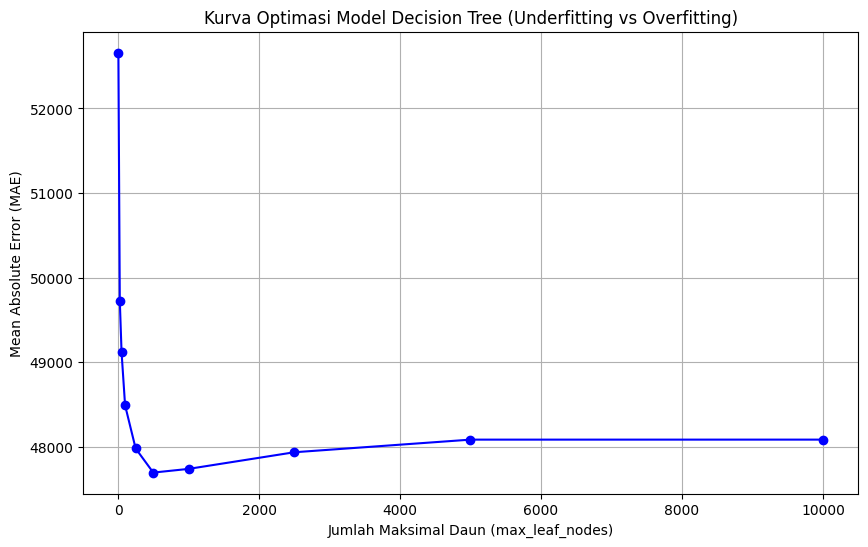

In [16]:
plt.figure(figsize=(10,6))
plt.plot(leaf_nodes, mae_values, marker='o', linestyle='-', color='b')

plt.title('Kurva Optimasi Model Decision Tree (Underfitting vs Overfitting)')
plt.xlabel('Jumlah Maksimal Daun (max_leaf_nodes)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True)

plt.show()

### Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

forest_model = RandomForestRegressor(random_state=0)
forest_model.fit(X_train, y_train)
salary_preds = forest_model.predict(X_test)
print(mean_absolute_error(y_test, salary_preds))

47628.086174946555


In [18]:
# Melihat daftar unik penulisan lokasi perusahaan
print("Daftar Lokasi Perusahaan:")
print(dataset_final['company_location'].unique())

# Melihat daftar unik profesi
print("\nDaftar Posisi Pekerjaan:")
print(dataset_final['job_title'].unique())

Daftar Lokasi Perusahaan:
['US' 'CA' 'NL' 'FR' 'GB' 'DE' 'ES' 'IE' 'AU' 'LT' 'IN' 'EE' 'SK' 'CZ'
 'UA' 'FI' 'CO' 'AR' 'AT' 'EG' 'SG' 'MX' 'IT' 'PL' 'BE' 'CH' 'GR' 'NZ'
 'HR' 'PR' 'PT' 'BR' 'PH' 'RO' 'ML' 'NO' 'CL' 'MY' 'SV' 'DO' 'GT' 'CR'
 'LV' 'ZA' 'JO' 'CY' 'TH' 'JM' 'JP' 'MT' 'MK' 'SI' 'HK' 'LS' 'PE' 'HU'
 'PA' 'LU' 'DZ' 'KE' 'CD' 'SE' 'KR' 'TW' 'TR' 'DK' 'AE' 'BG' 'ID' 'RS'
 'EC' 'XK' 'ZM' 'AM' 'IL' 'LB' 'NG' 'PK' 'HN' 'VE' 'AS' 'SA' 'OM' 'BA'
 'VN' 'GI' 'MU' 'RU' 'QA' 'GH' 'AD' 'CF' 'IR' 'BS' 'IQ' 'CN' 'MD']

Daftar Posisi Pekerjaan:
['Head of Data' 'Data Scientist' 'Engineer' 'AI Product Lead'
 'AI Engineer' 'Business Intelligence Engineer' 'Manager'
 'Computer Vision Engineer' 'Data Management' 'Product Manager'
 'Data Engineer' 'Machine Learning Engineer' 'Software Engineer'
 'Data Analyst' 'Research Scientist' 'Developer' 'Associate'
 'Computational Scientist' 'Analyst' 'AI Scientist' 'DataOps Engineer'
 'Prompt Engineer' 'Data Governance Engineer' 'Analytics Engineer'
 'AI Go

## Testing Model

In [25]:
#  0   work_year           71913 non-null  int64 
#  1   experience_level    71913 non-null  object
#  2   employment_type     71913 non-null  object
#  3   job_title           71913 non-null  object
#  4   salary_in_usd       71913 non-null  int64 
#  5   employee_residence  71913 non-null  object
#  6   remote_ratio        71913 non-null  int64 
#  7   company_location    71913 non-null  object
#  8   company_size        71913 non-null  object

# EN: Entry-level / Junior
# MI: Mid-level / Intermediate
# SE: Senior-level
# EX: Executive / Director

# FT: Full-time
# PT: Part-time
# CT: Contract
# FL: Freelance

# S: Small (1–50 employees)
# M: Medium (51–500 employees)
# L: Large (501+ employees)

# test data 
# work_year 2029
# experience level : SE (Senior Level)
# employment_type : Freelance 
# job_title : Frontend Developer 
# employee_residence : IND
# remote_ratio : 0 (no remote, onsite)
# company_location : Singapore
# company_size : 51-500

import numpy as np

# 1. BIKIN TABEL KOSONG (636 Kolom)
# Meminjam kerangka kolom dari variabel X saat pelatihan
data_tes = pd.DataFrame(columns=X.columns)
data_tes.loc[0] = np.zeros(len(X.columns)) 

# 2. ISI DATA NUMERIK (Angka murni)
data_tes['work_year'] = 2029
data_tes['remote_ratio'] = 0

# 3. ISI DATA KATEGORI (Yang harus diubah jadi angka 1)
# Kita gabungkan awalan kolom aslinya dengan nilai pilihanmu
kategori_aktif = [
    'experience_level_SE',             # SE: Senior Level
    'employment_type_FL',              # FL: Freelance
    'job_title_Data Analyst',    # Posisi
    'employee_residence_IN',          # Ingat: Dataset aslinya mungkin pakai kode ISO (misal: 'IN' atau 'ID')
    'company_location_US',      # Ingat: Mungkin di dataset ditulisnya 'SG'
    'company_size_M'                   # 51-500: Medium
]

# Looping cerdas: Nyalakan angka 1 jika kolomnya benar-benar ada di dalam daftar 636 kolom
print("Status Pengecekan Kolom:")
for kolom in kategori_aktif:
    if kolom in data_tes.columns:
        data_tes[kolom] = 1
        print(f"✔️ Berhasil memasukkan: {kolom}")
    else:
        # Peringatan ini muncul kalau format huruf besarnya beda, atau dataset aslinya pakai singkatan
        print(f"❌ Peringatan: '{kolom}' tidak ditemukan di daftar fitur model!")

# 4. TEBAK GAJI
# Menggunakan forest_model milikmu untuk memprediksi
tebakan = forest_model.predict(data_tes)

print("\n==================================")
print(f"🎯 ESTIMASI GAJI AI: $ {tebakan[0]:,.0f}")
print("==================================")


Status Pengecekan Kolom:
✔️ Berhasil memasukkan: experience_level_SE
✔️ Berhasil memasukkan: employment_type_FL
✔️ Berhasil memasukkan: job_title_Data Analyst
✔️ Berhasil memasukkan: employee_residence_IN
✔️ Berhasil memasukkan: company_location_US
✔️ Berhasil memasukkan: company_size_M

🎯 ESTIMASI GAJI AI: $ 79,198


## Import to joblib

In [ ]:
from sklearn.externals import joblib 

file_name = 'my_model_salary.pkl'
joblib.dump(forest_model, file_name)